# putEMG — Deep Learning Cross-Subject Models (LOSO)

Trains and evaluates deep learning architectures on the putEMG gesture dataset using
**Leave-One-Subject-Out (LOSO)** cross-validation. Set `MODEL_TYPE` in the config cell to switch models.

| Model | Description |
|-------|-------------|
| **EMG_TCN** | Spatial mixing + 4 dilated temporal conv blocks |
| **EEGNet** | Depthwise separable CNN |
| **ShallowConvNet** | Temporal + spatial conv, square/log nonlinearity |

**LOSO split (per fold):**
- **Test** — 1 held-out subject (never seen during training)
- **Val** — 10% of the remaining 43 subjects, stratified by class (early stopping only)
- **Train** — remaining 90% of those 43 subjects

Weights are saved per model under `weights/<MODEL_TYPE>/`; per-fold logs under `results/results_log_<MODEL_TYPE>.txt`.
Completed folds are skipped automatically — safe to stop and resume at any time.

> **Prerequisites**: Run `data_preprocessing/driver.ipynb` first to generate per-subject `.mat` files.

In [1]:
import os
import sys
import numpy as np
import datetime
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
# -- Shared utilities (src/) --
sys.path.append(os.path.abspath('../../../'))

import src.deep_learning_models as dlm
from src.emg_loader import load_all_subjects, make_loso_train_val_test

In [3]:
# ── Training & evaluation utilities ──────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def train(model, train_loader, criterion, optimizer, device):
    """One full epoch over train_loader. Returns mean batch loss."""
    model.train()   # enables dropout and batch-norm update
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()           # clear gradients from the previous batch
        out  = model(X)
        loss = criterion(out, y)        # cross-entropy between logits and true labels
        loss.backward()                 # backprop: compute gradients for all parameters
        optimizer.step()               # update weights using the computed gradients
        total_loss += loss.item()
    return total_loss / len(train_loader)   # mean loss across all batches


def evaluate(model, loader, device):
    """Returns top-1 accuracy over loader. No gradient computation."""
    model.eval()    # disables dropout, freezes batch-norm stats
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X).argmax(dim=1)   # predicted class = index of highest logit
            correct += (pred == y).sum().item()
            total   += y.size(0)
    return correct / total


def evaluateFinal(model, test_loader, device, plot=True):
    """Full evaluation with optional confusion matrix — use for post-hoc analysis."""
    model.eval()
    correct, total = 0, 0
    actual    = torch.tensor([], dtype=torch.int64)
    predicted = torch.tensor([], dtype=torch.int64)
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X).argmax(dim=1)
            correct   += (pred == y).sum().item()
            total     += y.size(0)
            # Accumulate all labels on CPU to build the confusion matrix after the loop
            actual    = torch.cat((actual,    y.cpu()),    dim=0)
            predicted = torch.cat((predicted, pred.cpu()), dim=0)

    acc = correct / total
    if plot:
        print(np.unique(predicted.numpy(), return_counts=True))
        cm = confusion_matrix(actual.numpy(), predicted.numpy())
        ConfusionMatrixDisplay(cm).plot()
    print(f'Test accuracy: {acc * 100:.2f}%')
    return acc

In [4]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [7]:
_notebook_dir = os.path.abspath(os.getcwd())
print(_notebook_dir)

/Users/chrisdollo/Documents/Research/putEMG prime/generalizable/baseline_models/deep_learning_approach


In [ ]:
# -- Paths --
DATA_DIR    = '/Volumes/KRIS/data/UG_per_subject'
MODEL_TYPE  = 'EMG_TCN'   # change to: 'EEGNet' or 'ShallowConvNet'
WEIGHTS_DIR = os.path.join(_notebook_dir, 'weights', MODEL_TYPE)
RESULTS_DIR = os.path.join(_notebook_dir, 'results')
LOG_PATH    = os.path.join(RESULTS_DIR, f'results_log_{MODEL_TYPE}.txt')

# -- Data split --
BATCH_SIZE = 16
VAL_FRAC   = 0.10     # fraction of training pool held out for early stopping (stratified)

# -- Training --
MAX_EPOCHS = 20
PATIENCE   = 5
MIN_DELTA  = 0.002
LR         = 1e-3
DROPOUT    = 0.1

os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
subjects = load_all_subjects(DATA_DIR)
print(f'\nWeights → {WEIGHTS_DIR}')
print(f'Log     → {LOG_PATH}')

---
## LOSO Training Loop

Trains the selected model (`MODEL_TYPE`) on every subject as a test fold:

- **Test** — 1 held-out subject, never seen during training
- **Train / Val** — all other 43 subjects, split 90/10 (stratified by class, seeded) within the pool

Checkpointing:
- Weights saved to `weights/<MODEL_TYPE>/<MODEL_TYPE>_<subject_id>.pt` after each fold
- If a checkpoint already exists the fold is skipped — safe to stop and resume at any time
- `results_log_<MODEL_TYPE>.txt` is rebuilt from all checkpoints after every fold

In [14]:
# ── Helpers ───────────────────────────────────────────────────────────────────

MODEL_MAP = {
    'EMG_TCN':        dlm.EMG_TCN,
    'EEGNet':         dlm.EEGNet,
    'ShallowConvNet': dlm.ShallowConvNet,
}

def subject_id(filename):
    """'emg_gestures_03_U.mat' → '03'"""
    return filename.replace('emg_gestures_', '').replace('_U.mat', '')


def weight_path(subject_name):
    return os.path.join(WEIGHTS_DIR, f'{MODEL_TYPE}_{subject_id(subject_name)}.pt')


def update_log():
    """Rebuild results_log_<MODEL_TYPE>.txt from all valid LOSO checkpoint files in WEIGHTS_DIR."""
    checkpoints = []
    for fname in sorted(os.listdir(WEIGHTS_DIR)):
        if not fname.endswith('.pt'):
            continue
        ckpt = torch.load(os.path.join(WEIGHTS_DIR, fname), map_location='cpu', weights_only=False)
        if 'subject' not in ckpt:
            continue
        checkpoints.append(ckpt)

    if not checkpoints:
        return

    accs    = [c['test_acc'] * 100 for c in checkpoints]
    n_done  = len(checkpoints)
    n_total = len(subjects)

    lines = [
        f'putEMG — {MODEL_TYPE} LOSO Results',
        '=' * 68,
        f"{'Subject':<28} {'Test Acc':>9}  {'Val Acc':>9}  {'Epoch':>6}  {'Date'}",
        '-' * 68,
    ]
    for c in checkpoints:
        lines.append(
            f"{c['subject']:<28} {c['test_acc']*100:>8.2f}%  "
            f"{c['val_acc']*100:>8.2f}%  {c['best_epoch']:>6}  {c['date']}"
        )
    lines += [
        '=' * 68,
        f"Mean: {np.mean(accs):.2f}%  ±  {np.std(accs):.2f}%  "
        f"({n_done} / {n_total} folds complete)",
    ]

    with open(LOG_PATH, 'w') as f:
        f.write('\n'.join(lines) + '\n')

    print(f"Log updated → {LOG_PATH}  ({n_done}/{n_total} folds)")

In [15]:
# ── LOSO outer loop: iterate over every subject as the held-out test fold ─────
# Each iteration trains a fresh model on all OTHER subjects and tests on this one.
# Checkpointing: if a .pt file already exists for a subject, skip that fold —
# this makes it safe to interrupt and resume without re-training completed folds.
for test_idx, (test_name, _, _) in enumerate(subjects):
    wpath = weight_path(test_name)

    # Resume support: skip folds that already have a saved checkpoint
    if os.path.exists(wpath):
        print(f"[SKIP] {test_name}  — checkpoint found")
        continue

    print(f"\n{'='*60}")
    print(f"  Fold {test_idx+1}/{len(subjects)}  —  test: {test_name}")
    print(f"{'='*60}")

    # Build dataloaders for this fold:
    #   - test_loader  : only the held-out subject (never used during training)
    #   - train_loader : 90% of the remaining 43 subjects (stratified split)
    #   - val_loader   : the other 10%, used only for early stopping
    train_loader, val_loader, test_loader = make_loso_train_val_test(
        subjects, test_idx, val_frac=VAL_FRAC, batch_size=BATCH_SIZE
    )

    # Fresh model + optimizer for every fold — no weight leakage between subjects
    model     = MODEL_MAP[MODEL_TYPE](dropout_rate=DROPOUT).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    # Halve LR when val accuracy plateaus; protects against overshooting the optimum
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)
    criterion = nn.CrossEntropyLoss()

    # Track the best validation checkpoint for early stopping
    best_val_acc = float('-inf')
    best_state   = None   # deep-copy of model weights at the best val epoch
    best_epoch   = 0
    bad_epochs   = 0      # consecutive epochs without a MIN_DELTA improvement

    # ── Inner loop: train for up to MAX_EPOCHS, stop early if val stagnates ──
    for epoch in range(MAX_EPOCHS):
        # One full pass over the training set; returns mean cross-entropy loss
        tr_loss = train(model, train_loader, criterion, optimizer, device)
        # Evaluate on the validation set (no gradients, no label leakage from test)
        val_acc = evaluate(model, val_loader, device)
        curr_lr = optimizer.param_groups[0]['lr']

        # Snapshot the weights whenever this epoch beats the previous best val accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            # Clone to CPU so GPU/MPS memory isn't held while training continues
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch   = epoch + 1

        # Update LR scheduler with current val accuracy (mode='max')
        scheduler.step(val_acc)
        # Increment the stagnation counter; reset it if we're still within MIN_DELTA of the best
        bad_epochs = 0 if val_acc >= (best_val_acc - MIN_DELTA) else bad_epochs + 1

        print(f"  Epoch {epoch+1:3d}: loss={tr_loss:.4f}  val={val_acc*100:.2f}%  "
              f"best={best_val_acc*100:.2f}%  lr={curr_lr:.2e}")

        # Stop early if validation hasn't improved for PATIENCE consecutive epochs
        if bad_epochs >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}.")
            break

    # Restore the best-seen weights before evaluating on the held-out test subject
    model.load_state_dict(best_state)
    test_acc = evaluate(model, test_loader, device)
    print(f"\n  Test accuracy: {test_acc*100:.2f}%")

    # Save checkpoint with metadata so update_log() can rebuild the results file
    torch.save({
        'subject':    test_name,
        'test_acc':   test_acc,
        'val_acc':    best_val_acc,
        'best_epoch': best_epoch,
        'dropout':    DROPOUT,
        'state_dict': best_state,
        'date':       datetime.date.today().isoformat(),
    }, wpath)

    # Rebuild the log after every fold so progress is visible without waiting for completion
    update_log()

print(f"\n{'='*60}")
print("  All folds complete.")
print(f"{'='*60}")
update_log()


  Fold 1/44  —  test: emg_gestures_03_U.mat
  Test  : emg_gestures_03_U.mat  (280 reps)
  Train : 10836 reps  |  Val: 1204 reps  (43 subjects, 90/10 split)
  Epoch   1: loss=1.0871  val=68.02%  best=68.02%  lr=1.00e-03
  Epoch   2: loss=0.8310  val=73.09%  best=73.09%  lr=1.00e-03
  Epoch   3: loss=0.7221  val=76.58%  best=76.58%  lr=1.00e-03
  Epoch   4: loss=0.6662  val=72.51%  best=76.58%  lr=1.00e-03
  Epoch   5: loss=0.6267  val=79.32%  best=79.32%  lr=1.00e-03
  Epoch   6: loss=0.5516  val=78.07%  best=79.32%  lr=1.00e-03
  Epoch   7: loss=0.5467  val=79.57%  best=79.57%  lr=1.00e-03
  Epoch   8: loss=0.5133  val=77.66%  best=79.57%  lr=1.00e-03
  Epoch   9: loss=0.4965  val=77.41%  best=79.57%  lr=1.00e-03
  Epoch  10: loss=0.4862  val=81.98%  best=81.98%  lr=1.00e-03
  Epoch  11: loss=0.4427  val=70.35%  best=81.98%  lr=1.00e-03
  Epoch  12: loss=0.4488  val=74.25%  best=81.98%  lr=1.00e-03
  Epoch  13: loss=0.4340  val=81.48%  best=81.98%  lr=1.00e-03
  Epoch  14: loss=0.4266

---
## Results

putEMG — ShallowConvNet LOSO Results
Subject                       Test Acc    Val Acc   Epoch  Date
--------------------------------------------------------------------
emg_gestures_03_U.mat           77.50%     81.98%      10  2026-04-21
emg_gestures_04_U.mat           70.71%     82.89%       9  2026-04-21
emg_gestures_05_U.mat           63.57%     84.39%      17  2026-04-21
emg_gestures_06_U.mat           48.93%     84.63%      14  2026-04-21
emg_gestures_07_U.mat           53.93%     79.82%       5  2026-04-21
emg_gestures_08_U.mat           71.79%     83.80%      11  2026-04-21
emg_gestures_09_U.mat           78.21%     82.14%       9  2026-04-21
emg_gestures_10_U.mat           85.00%     83.22%      18  2026-04-21
emg_gestures_11_U.mat           63.57%     84.30%      13  2026-04-21
emg_gestures_12_U.mat           66.79%     81.23%      12  2026-04-21
emg_gestures_13_U.mat           81.79%     83.97%      20  2026-04-21
emg_gestures_14_U.mat           86.43%     81.81%      20  2

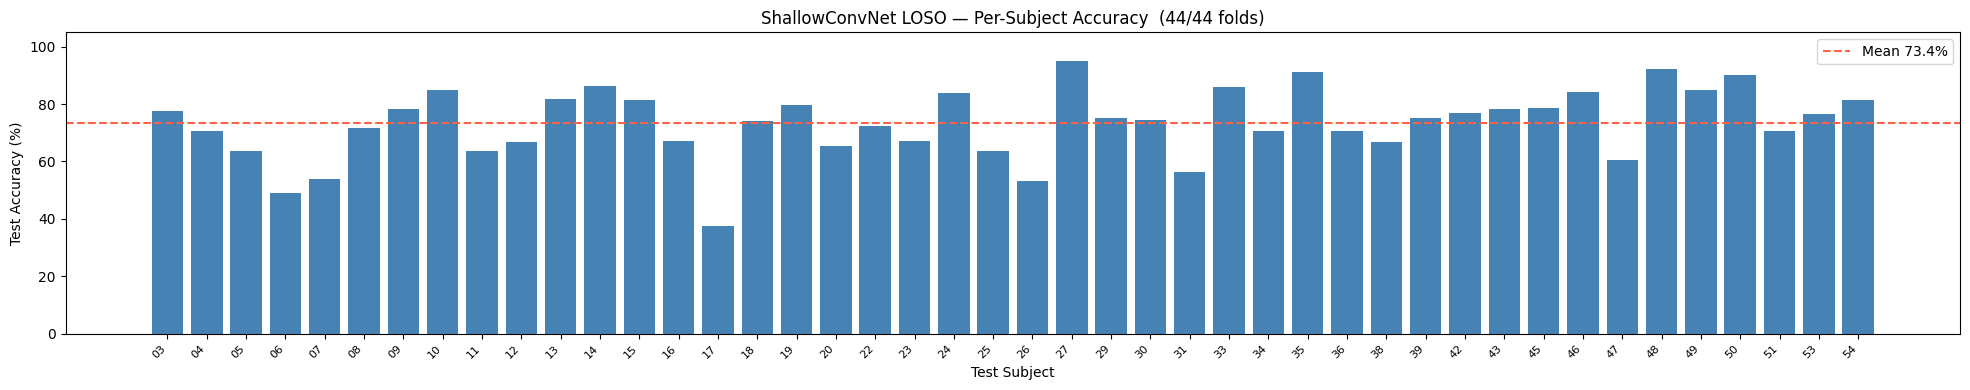

In [16]:
# ── Print log ─────────────────────────────────────────────────────────────────
if os.path.exists(LOG_PATH):
    with open(LOG_PATH) as f:
        print(f.read())
else:
    print("No results yet — run the training loop first.")

# ── Bar chart ─────────────────────────────────────────────────────────────────
checkpoints = []
for fname in sorted(os.listdir(WEIGHTS_DIR)):
    if not fname.endswith('.pt'):
        continue
    ckpt = torch.load(os.path.join(WEIGHTS_DIR, fname), map_location='cpu', weights_only=False)
    if 'subject' not in ckpt:   # skip old-format checkpoints
        continue
    checkpoints.append(ckpt)

if checkpoints:
    sids  = [subject_id(c['subject']) for c in checkpoints]
    accs  = [c['test_acc'] * 100 for c in checkpoints]
    mean  = np.mean(accs)

    fig, ax = plt.subplots(figsize=(max(10, len(sids) * 0.45), 4))
    ax.bar(sids, accs, color='steelblue')
    ax.axhline(mean, color='tomato', linestyle='--', linewidth=1.5, label=f'Mean {mean:.1f}%')
    ax.set_ylim(0, 105)
    ax.set_xlabel('Test Subject')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(f'{MODEL_TYPE} LOSO — Per-Subject Accuracy  ({len(checkpoints)}/{len(subjects)} folds)')
    ax.legend()
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()